<a href="https://colab.research.google.com/github/dilekmirac/goruntu_isleme/blob/main/hafta2_g%C3%B6rev1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import torch

print(f"OpenCV Versiyonu: {cv2.__version__}")
print(f"CUDA Kullanılabilir mi (PyTorch/GPU): {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"Aktif GPU Modeli: {torch.cuda.get_device_name(0)}")

OpenCV Versiyonu: 5.0.0
CUDA Kullanılabilir mi (PyTorch/GPU): True
Aktif GPU Modeli: Tesla T4


'resim_klasoru' adında yeni bir klasör oluşturuldu.
Resim başarıyla 'resim_klasoru/hedef_resim.jpg' yoluna yerleştirildi.
Orijinal Resim Boyutu: 678x452
Yeniden Boyutlandırılmış Boyut: 1024x768


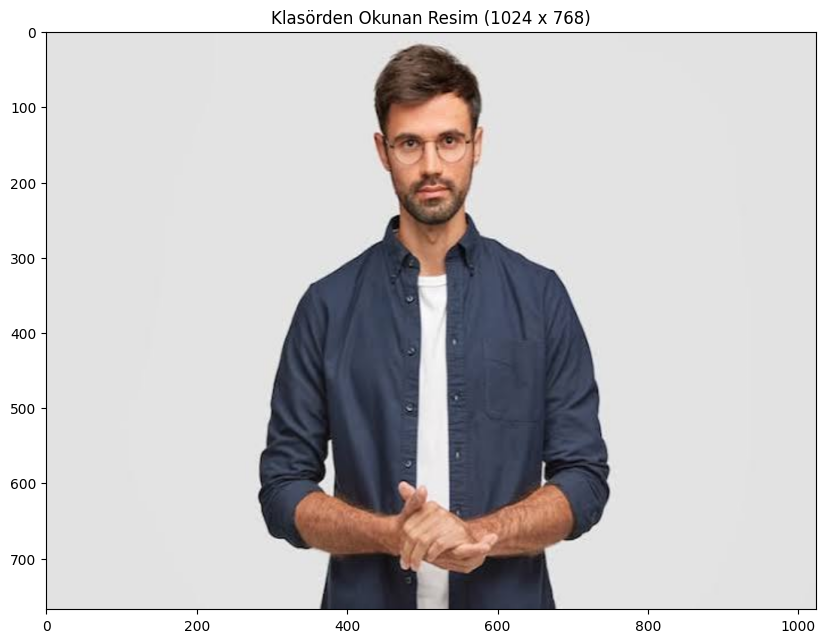

In [ ]:
import os
import cv2
import shutil
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# 1. Python Kodu ile Bir Klasör Oluşturma (Açma)
# -------------------------------------------------------------------------
klasor_adi = "resim_klasoru"

# Klasör yoksa oluştur
if not os.path.exists(klasor_adi):
    os.makedirs(klasor_adi)
    print(f"'{klasor_adi}' adında yeni bir klasör oluşturuldu.")
else:
    print(f"'{klasor_adi}' klasörü zaten mevcut.")

# Önceki adımdan yüklediğimiz 'insan.jpg' dosyasını bu klasörün içine kopyalayalım
kaynak_resim = "insan.jpg"
hedef_resim_yolu = os.path.join(klasor_adi, "hedef_resim.jpg")

if os.path.exists(kaynak_resim):
    shutil.copy(kaynak_resim, hedef_resim_yolu)
    print(f"Resim başarıyla '{hedef_resim_yolu}' yoluna yerleştirildi.")
else:
    raise FileNotFoundError("Ana dizinde 'insan.jpg' bulunamadı! Lütfen görseli yükleyin.")

# -------------------------------------------------------------------------
# 2. Klasörün İçindeki Resmi Okuma
# -------------------------------------------------------------------------
img = cv2.imread(hedef_resim_yolu)

if img is None:
    raise FileNotFoundError("Resim klasörden okunamadı!")

orijinal_h, orijinal_w = img.shape[:2]
print(f"Orijinal Resim Boyutu: {orijinal_w}x{orijinal_h}")

# -------------------------------------------------------------------------
# 3. Resmi 1024 x 768 Boyutuna Getirme (Genişlik: 1024, Yükseklik: 768)
# OpenCV resize fonksiyonunda format: (genişlik, yükseklik)
# -------------------------------------------------------------------------
hedef_genislik = 1024
hedef_yukseklik = 768

img_resized = cv2.resize(img, (hedef_genislik, hedef_yukseklik), interpolation=cv2.INTER_LINEAR)
yeni_h, yeni_w = img_resized.shape[:2]
print(f"Yeniden Boyutlandırılmış Boyut: {yeni_w}x{yeni_h}")

# -------------------------------------------------------------------------
# 4. Resmi Ekranda Gösterme
# -------------------------------------------------------------------------
# OpenCV renkleri BGR okur, ekranda doğru görmek için RGB'ye çeviriyoruz
img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 7.5))
plt.imshow(img_rgb)
plt.title(f"Klasörden Okunan Resim ({yeni_w} x {yeni_h})")
plt.axis('on')  # Eksenleri açık bıraktık ki 1024 ve 768 cetvelleri gözüksün
plt.show()